In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [39]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.preprocessing as preProcess

In [7]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


## Loading the Samples + DataFrame

In [25]:
# Inserire il nome del sample:
sample_TT = "TTToHadronic_btag_500k.npz"
data_TT = np.load(sample_TT)

In [33]:
 # first check : reco vs gen for fake taus
taus_kin = data_TT["x_taus"][:, :, :4]
gen = data_TT["x_gen"]

diff = np.abs(taus_kin - gen)

print("max difference =", diff.max())
print("mean difference =", diff.mean())

max difference = 0.0002495472926966613
mean difference = 7.527885606345146e-07


In [34]:
import numpy as np
import pandas as pd

data_TT = np.load("TTToHadronic_btag_500k.npz", allow_pickle=True)

x_taus = data_TT["x_taus"]
x_met  = data_TT["x_met"]
x_jets = data_TT["x_jets"]
x_gen  = data_TT["x_gen"]

N = x_taus.shape[0]

tau_features = [
    "pt", "eta", "phi", "mass",
    "dxy", "dz", "ptCorrPNet",
    "rawPNetVSjet", "rawDeepTau2018v2p5VSjet",
    "charge",
    "dM_0", "dM_1", "dM_2", "dM_10", "dM_11",
    "leadTkDeltaEta", "leadTkDeltaPhi",
    "leadTkPtOverTauPt"
]

met_features = [
    "pt", "phi", "covXX", "covXY",
    "covYY", "significance",
    "sumEt", "sumPtUnclustered"
]

jet_features = [
    "pt", "eta", "phi", "mass",
    "btagDeepFlavB",
    "btagDeepFlavCvB",
    "btagDeepFlavCvL",
    "btagDeepFlavQG",
    "btagPNetB",
    "btagPNetCvB",
    "btagPNetCvL",
    "btagPNetQvG",
    "btagPNetTauVJet",
    "btagRobustParTAK4B",
    "btagRobustParTAK4CvB",
    "btagRobustParTAK4CvL",
    "btagRobustParTAK4QG"
]

gen_features = ["pt", "eta", "phi", "mass"]

cols = {}

# Taus
for itau in range(2):
    for ifeat, feat in enumerate(tau_features):
        cols[f"tau{itau+1}_{feat}"] = x_taus[:, itau, ifeat]

# MET
for ifeat, feat in enumerate(met_features):
    cols[f"MET_{feat}"] = x_met[:, 0, ifeat]

# Jets
for ijet in range(3):
    for ifeat, feat in enumerate(jet_features):
        cols[f"jet{ijet+1}_{feat}"] = x_jets[:, ijet, ifeat]

# Gen / target
for itau in range(2):
    for ifeat, feat in enumerate(gen_features):
        cols[f"tau{itau+1}_gen_{feat}"] = x_gen[:, itau, ifeat]

# Event variables
cols["m_vis"] = data_TT["m_vis"]
cols["m_vis_ptcorr"] = data_TT["m_vis_ptcorr"]
cols["m_gen"] = data_TT["m_gen"]
cols["m_fastmtt"] = data_TT["m_fastmtt"]

df_TT = pd.DataFrame(cols)

df_TT["process"] = "TTbar"
df_TT["label"] = 2

print(df_TT.shape)
df_TT.head()

(500000, 109)


,tau1_pt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_gen_pt,tau2_gen_eta,tau2_gen_phi,tau2_gen_mass,m_vis,m_vis_ptcorr,m_gen,m_fastmtt,process,label
0,34.571736,-0.565674,-1.757568,1.269531,-0.012032,-0.011731,0.951172,0.001021,0.471924,1.0,...,27.494320,-0.500977,1.563232,0.885254,61.484100,59.555413,61.484100,84.089897,TTbar,2
1,91.819176,-0.633179,1.982178,0.460938,0.000022,-0.000385,1.125000,0.119568,0.533691,-1.0,...,20.552887,0.001348,2.991699,0.854980,50.556320,50.532768,50.556328,70.223686,TTbar,2
2,38.537060,-1.734375,0.224121,1.171875,0.000075,-0.032043,1.013672,0.001110,0.212280,1.0,...,33.632610,-1.010254,-0.462830,8.234375,38.892656,35.345870,38.892632,48.993340,TTbar,2
3,38.045388,-0.597046,-2.884277,1.277344,-0.050964,0.042227,1.117188,0.000395,0.546387,-1.0,...,21.951897,-0.258972,-0.132599,4.023438,57.984462,62.998521,57.984451,71.589851,TTbar,2
4,52.906571,1.438721,-1.941406,8.625000,-0.004173,0.000908,0.916504,0.063110,-1.000000,-1.0,...,31.081190,-1.508301,0.193909,1.190430,182.468579,188.716894,182.468597,246.844971,TTbar,2


In [48]:
# colonne aggiuntive come DY-H:
eps = 1e-8

df_TT["tau1_logpt"] = np.log(np.clip(df_TT["tau1_pt"], eps, None))
df_TT["tau2_logpt"] = np.log(np.clip(df_TT["tau2_pt"], eps, None))

df_TT["tau1_gen_logpt"] = np.log(np.clip(df_TT["tau1_gen_pt"], eps, None))
df_TT["tau2_gen_logpt"] = np.log(np.clip(df_TT["tau2_gen_pt"], eps, None))

df_TT["tau1_pt_reco"] = df_TT["tau1_pt"]
df_TT["tau2_pt_reco"] = df_TT["tau2_pt"]

df_TT["tau1_pt_reco_corrPNet"] = df_TT["tau1_pt_reco"] * df_TT["tau1_ptCorrPNet"]
df_TT["tau2_pt_reco_corrPNet"] = df_TT["tau2_pt_reco"] * df_TT["tau2_ptCorrPNet"]

df_TT["tau1_corr"] = df_TT["tau1_gen_pt"] / np.clip(df_TT["tau1_pt_reco_corrPNet"], eps, None)
df_TT["tau2_corr"] = df_TT["tau2_gen_pt"] / np.clip(df_TT["tau2_pt_reco_corrPNet"], eps, None)

for j in [1, 2, 3]:
    df_TT_pt[f"jet{j}_logpt"] = np.log(np.clip(df_TT_pt[f"jet{j}_pt"], eps, None))

## Checks

In [11]:
df.filter(regex="btag").describe()

,jet1_btagDeepFlavB,jet1_btagDeepFlavCvB,jet1_btagDeepFlavCvL,jet1_btagDeepFlavQG,jet1_btagPNetB,jet1_btagPNetCvB,jet1_btagPNetCvL,jet1_btagPNetQvG,jet1_btagPNetTauVJet,jet1_btagRobustParTAK4B,...,jet3_btagDeepFlavQG,jet3_btagPNetB,jet3_btagPNetCvB,jet3_btagPNetCvL,jet3_btagPNetQvG,jet3_btagPNetTauVJet,jet3_btagRobustParTAK4B,jet3_btagRobustParTAK4CvB,jet3_btagRobustParTAK4CvL,jet3_btagRobustParTAK4QG
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.353765,0.552017,0.402820,0.605205,0.289926,0.476485,0.431678,0.497647,-0.059962,0.199535,...,0.657680,0.068816,0.411886,0.194715,0.377132,-0.145287,-0.200508,0.314243,0.130434,0.377180
std,0.421584,0.372486,0.379730,0.223528,0.540269,0.551969,0.545942,0.244965,0.246166,0.937055,...,0.197091,0.574706,0.682710,0.618793,0.693322,0.363736,1.238710,0.637691,0.581239,0.616030
min,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-10.000000,-1.000000,-3.000000,...,0.000000,-1.000000,-1.000000,-1.000000,-10.000000,-1.000000,-3.000000,-1.000000,-1.000000,-1.000000
25%,0.009033,0.082153,0.063599,0.421143,0.006004,0.008835,0.082397,0.325928,0.000269,0.009537,...,0.517090,0.004467,0.007076,0.063049,0.248901,0.000203,0.007416,0.001727,0.048615,0.327881
50%,0.055023,0.730469,0.175415,0.621582,0.036102,0.793945,0.315186,0.511719,0.000659,0.073181,...,0.685059,0.016220,0.813477,0.135376,0.403076,0.000686,0.031921,0.589844,0.096802,0.592773
75%,0.899902,0.880859,0.840332,0.801758,0.949219,0.931152,0.980469,0.682617,0.001394,0.984375,...,0.821777,0.213013,0.915039,0.787598,0.577637,0.001700,0.379944,0.813965,0.440430,0.780273
max,0.999512,0.986328,0.999512,0.979980,0.999512,0.998047,0.999512,0.999512,0.991211,1.000000,...,0.975098,0.999512,0.998047,0.999512,0.999512,0.995605,0.999512,0.995117,0.999512,0.978027


In [12]:
for j in [1,2,3]:
    print(f"jet{j}")
    print(df[f"jet{j}_pt"].describe())
    print()

jet1
count    500000.000000
mean        109.165886
std          59.344521
min           1.000000
25%          73.000015
50%          94.875000
75%         127.625008
max        1677.000000
Name: jet1_pt, dtype: float64

jet2
count    500000.000000
mean         74.607727
std          39.241196
min           1.000000
25%          50.218754
50%          65.812515
75%          88.249992
max        1174.000000
Name: jet2_pt, dtype: float64

jet3
count    500000.000000
mean         50.377087
std          25.261093
min           1.000000
25%          33.624996
50%          45.531246
75%          60.843761
max         818.499939
Name: jet3_pt, dtype: float64



In [13]:
for j in [1,2,3]:
    print(
        j,
        (df[f"jet{j}_pt"] == 0).mean()
    )

1 0.0
2 0.0
3 0.0


In [14]:
btag_cols = [
    "jet1_btagDeepFlavB",
    "jet2_btagDeepFlavB",
    "jet3_btagDeepFlavB",
    "jet1_btagPNetB",
    "jet2_btagPNetB",
    "jet3_btagPNetB",
]

df[btag_cols].describe()

,jet1_btagDeepFlavB,jet2_btagDeepFlavB,jet3_btagDeepFlavB,jet1_btagPNetB,jet2_btagPNetB,jet3_btagPNetB
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,0.353765,0.304051,0.226994,0.289926,0.212274,0.068816
std,0.421584,0.400001,0.353573,0.540269,0.557456,0.574706
min,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000
25%,0.009033,0.009079,0.009880,0.006004,0.005516,0.004467
50%,0.055023,0.038757,0.032898,0.036102,0.024612,0.016220
75%,0.899902,0.720703,0.262207,0.949219,0.799805,0.213013
max,0.999512,0.999512,0.999512,0.999512,0.999512,0.999512


In [15]:
for col in btag_cols:
    print(
        col,
        " zeros = ",
        (df[col] == 0).mean()
    )

jet1_btagDeepFlavB  zeros =  1.4e-05
jet2_btagDeepFlavB  zeros =  0.000416
jet3_btagDeepFlavB  zeros =  0.005528
jet1_btagPNetB  zeros =  1.4e-05
jet2_btagPNetB  zeros =  0.000416
jet3_btagPNetB  zeros =  0.005528


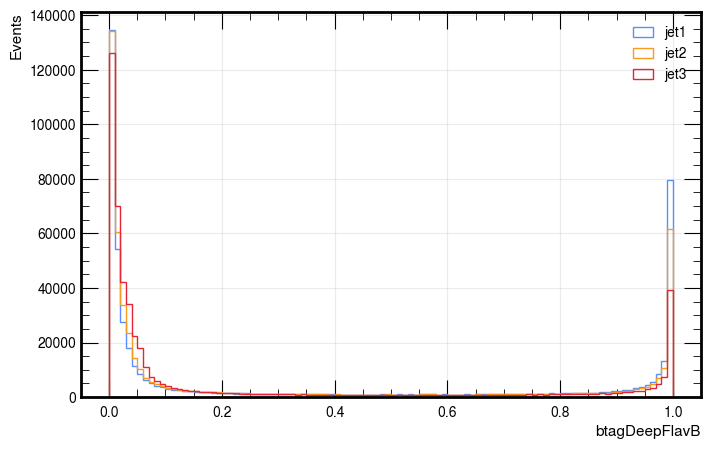

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["jet1_btagDeepFlavB"],
    bins=100,
    histtype="step",
    label="jet1"
)

plt.hist(
    df["jet2_btagDeepFlavB"],
    bins=100,
    histtype="step",
    label="jet2"
)

plt.hist(
    df["jet3_btagDeepFlavB"],
    bins=100,
    histtype="step",
    label="jet3"
)

plt.xlabel("btagDeepFlavB")
plt.ylabel("Events")
plt.legend()
plt.show()

In [17]:
# Frazione di jet altamente b-tagged:
for c in [
    "jet1_btagDeepFlavB",
    "jet2_btagDeepFlavB",
    "jet3_btagDeepFlavB"
]:
    print(
        c,
        (df[c] > 0.8).mean()
    )

jet1_btagDeepFlavB 0.283008
jet2_btagDeepFlavB 0.231462
jet3_btagDeepFlavB 0.157314


In [20]:
# i jet sono ordinati per pT?

(
    df["jet1_pt"] >= df["jet2_pt"]
).mean()

np.float64(1.0)

In [21]:
(
    df["jet2_pt"] >= df["jet3_pt"]
).mean()

np.float64(1.0)

In [23]:
df["best_btag"] = df[
    [
        "jet1_btagDeepFlavB",
        "jet2_btagDeepFlavB",
        "jet3_btagDeepFlavB"
    ]
].max(axis=1)

df["second_btag"] = np.sort(
    df[
        [
            "jet1_btagDeepFlavB",
            "jet2_btagDeepFlavB",
            "jet3_btagDeepFlavB"
        ]
    ].values,
    axis=1
)[:, -2]

df[["best_btag","second_btag"]].describe()

,best_btag,second_btag
count,500000.000000,500000.000000
mean,0.665808,0.198492
std,0.388721,0.307728
min,0.000000,0.000000
25%,0.238525,0.014351
50%,0.905762,0.038544
75%,0.996094,0.213501
max,0.999512,0.999512


In [24]:
(
    df["second_btag"] > 0.8
).mean()

np.float64(0.105906)

---
### Il sample TTbar è tale che:

    - x_gen = x_reco (circa)
    - i fake tau hanno target = reco 
    - I jet contengono info di b-tagging
    - I jet sono ordinati per pT
    - I primi due jet sembrano quelli più interessanti dal punto di vista fisico

--- 

## Pre-Processing

In [37]:
# Tolgo gli eventi con correzione PNet == 0 , richiedendo che il pT reco sia > 0:
mask = (
    (df_TT["tau1_pt_reco_corrPNet"] > 0) &
    (df_TT["tau2_pt_reco_corrPNet"] > 0)
)

df_TT = df_TT.loc[mask].copy()

In [42]:
# pT cut 

pt_cfg = preProcess.PtCutConfig(
    pt_min=30.0,
    space="pt",
    tau1_pt_col="tau1_pt_reco",
    tau2_pt_col="tau2_pt_reco",
)

df_TT_pt = preProcess.apply_pt_cut(df_TT, pt_cfg)

In [44]:
print("DY:", len(df_TT), "->", len(df_TT_pt))

DY: 499914 -> 139920


In [60]:
df_TT_pt_jets = preProcess.apply_jet_selection(df_TT_pt, pt_min_jet=20.0)
cutflow_df = pd.DataFrame({
    "step": ["raw", "tau_pt", "jets"],
    "TTbar": [len(df_TT), len(df_TT_pt), len(df_TT_pt_jets)],
})
cutflow_df

,step,TTbar
0,raw,499914
1,tau_pt,139920
2,jets,139214


In [52]:
# valid taus:
tauid_cfg = preProcess.TauIDConfig(
    tau1_id_col="tau1_rawPNetVSjet",
    tau2_id_col="tau2_rawPNetVSjet",
    invalid_value=-1.0,
)

df_TT_valid = preProcess.filter_valid_tauid(df_TT_pt_jets, tauid_cfg)

# check
print("DY after pt:", len(df_TT_pt_jets), "-> after valid tauID:", len(df_TT_valid))

assert (df_TT_valid["tau1_rawPNetVSjet"] != -1).all()
assert (df_TT_valid["tau2_rawPNetVSjet"] != -1).all()

print("valid tauID OK (no -1)")

DY after pt: 139214 -> after valid tauID: 138480
valid tauID OK (no -1)


In [55]:
# Applico le soglie della tau ID calcolate su Higgs:
import json

with open("tauid_thresholds_90eff_higgs.json", "r") as f:
    tauid_thresholds = json.load(f)

thr1 = tauid_thresholds["thr1"]
thr2 = tauid_thresholds["thr2"]

print(thr1, thr2)

df_TT_tauid = preProcess.apply_tauid_wp(
    df_TT_valid,
    tauid_cfg,
    thr1,
    thr2
)

rows = []

for sample, df_before, df_after in [
    ("TT", df_TT_valid, df_TT_tauid),
]:

    before = len(df_before)
    after = len(df_after)
    removed = before - after
    removed_pct = 100 * removed / before

    rows.append({
        "sample": sample,
        "cut": f"tauID WP (target_eff = 0.90, reference = Higgs",
        "before": before,
        "after": after,
        "removed": removed,
        "removed_%": removed_pct,
    })

cutflow_tauID_WP = pd.DataFrame(rows)
cutflow_tauID_WP["removed_%"] = cutflow_tauID_WP["removed_%"].round(2)

cutflow_tauID_WP

0.6416015625 0.46875


,sample,cut,before,after,removed,removed_%
0,TT,"tauID WP (target_eff = 0.90, reference = Higgs",138480,2780,135700,97.99


In [56]:
print("Before tauID:", len(df_TT_pt_jets))

print("thr1 =", thr1)
print("thr2 =", thr2)

print(df_TT_pt_jets[["tau1_rawPNetVSjet", "tau2_rawPNetVSjet"]].describe())

pass_tau1 = df_TT_pt_jets["tau1_rawPNetVSjet"] > thr1
pass_tau2 = df_TT_pt_jets["tau2_rawPNetVSjet"] > thr2

print("pass tau1:", pass_tau1.mean())
print("pass tau2:", pass_tau2.mean())
print("pass both:", (pass_tau1 & pass_tau2).mean())
print("N pass both:", (pass_tau1 & pass_tau2).sum())

Before tauID: 139214
thr1 = 0.6416015625
thr2 = 0.46875
       tau1_rawPNetVSjet  tau2_rawPNetVSjet
count      139214.000000      139214.000000
mean            0.225904           0.205379
std             0.282385           0.265480
min            -1.000000          -1.000000
25%             0.025269           0.027195
50%             0.102295           0.098999
75%             0.322510           0.284180
max             0.999512           0.999512
pass tau1: 0.12250204720789576
pass tau2: 0.1570675363110032
pass both: 0.01996925596563564
N pass both: 2780


In [57]:
df_TT_event = df_TT_valid.copy()

In [58]:
df_TT_event

,tau1_pt,tau1_eta,tau1_phi,tau1_mass,tau1_dxy,tau1_dz,tau1_ptCorrPNet,tau1_rawPNetVSjet,tau1_rawDeepTau2018v2p5VSjet,tau1_charge,...,tau2_gen_logpt,tau1_pt_reco,tau2_pt_reco,tau1_pt_reco_corrPNet,tau2_pt_reco_corrPNet,tau1_corr,tau2_corr,jet1_logpt,jet2_logpt,jet3_logpt
2,38.537060,-1.734375,0.224121,1.171875,0.000075,-0.032043,1.013672,0.001110,0.212280,1.0,...,3.515496,38.537060,33.632614,39.063934,25.158772,0.986512,1.336814,4.510859,4.227746,3.993027
4,52.906571,1.438721,-1.941406,8.625000,-0.004173,0.000908,0.916504,0.063110,-1.000000,-1.0,...,3.436603,52.906571,31.081191,48.489079,36.271507,1.091103,0.856904,4.572130,4.430072,4.193436
5,40.541168,-2.098145,0.881714,0.139526,0.020142,-0.011328,1.184570,0.982910,0.893066,1.0,...,3.590837,40.541168,36.264399,48.023864,37.078932,0.844188,0.978033,4.380463,3.817712,3.442019
6,52.089908,1.399658,-2.257812,0.963867,0.001261,-0.003267,1.008789,0.058533,0.450195,1.0,...,3.531541,52.089908,34.176605,52.547729,35.645131,0.991287,0.958801,4.267072,3.972648,3.857435
7,78.665135,-0.891113,0.284973,1.264648,-0.002396,0.001227,1.023438,0.951660,0.857422,-1.0,...,3.791600,78.665135,44.327277,80.508849,38.613214,0.977099,1.147982,4.990433,4.204693,4.069561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499992,31.095577,0.123779,1.638428,0.836426,-0.000400,0.003535,0.983398,0.893555,0.990234,-1.0,...,3.424927,31.095577,30.720395,30.579342,30.930397,1.016882,0.993211,4.300681,3.982598,3.387563
499993,50.545201,-1.362549,-0.209351,0.139526,0.000678,0.000767,1.004883,0.083740,0.101501,-1.0,...,3.445554,50.545201,31.360668,50.792004,30.304083,0.995141,1.034866,4.744389,4.396761,4.338923
499994,42.094759,0.789673,1.593262,1.162109,-0.006138,-0.003655,1.038086,0.196777,0.904785,-1.0,...,3.467380,42.094759,32.052648,43.697977,22.959587,0.963311,1.396046,5.055449,4.862715,3.638408
499995,45.786690,1.269287,2.441895,1.281250,-0.010384,-0.035410,1.016602,0.089783,0.212402,-1.0,...,3.407101,45.786690,30.177644,46.546821,32.888917,0.983669,0.917563,4.971548,4.246708,4.245813


In [61]:
df_TT_event.to_pickle("df_TT_event+btag.pkl")